# AOD vs PM2.5 — Nghia Do (AERONET) ↔ closest Envisoft

Scatter plot + collocations of column AOD (AERONET, 550 nm) against surface PM2.5 (envisoft hourly) at the AERONET Nghia Do site and the geographically closest envisoft station.

**Time-zone convention**: AERONET timestamps are **UTC**; envisoft hourly PM2.5 is **UTC+7** (Vietnam local). All joins happen in local time.

**Collocation rule**: for each envisoft PM2.5 hour `H` (local), the AOD value is the mean of all AERONET observations whose local-time floor equals `H`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

AERONET_SITES   = Path('/home/work1/projects/Air_Quality/Masterdata/AERONET_sites.csv')
ENVISOFT_MAP    = Path('/home/work1/projects/Air_Quality/Masterdata/envisoft_station_map.csv')
AERONET_CSV     = Path('/home/slow_data/Air_Quality/AERONET/process/aod_550/10/NGHIA_DO.csv')
AQI_DIR         = Path('/home/slow_data/Air_Quality/AQI/process')

AERONET_STATION = 'NGHIA_DO'   # case matches AERONET_sites.csv stationName
LOCAL_TZ_HOURS  = 7            # Vietnam local time (UTC+7)
DAYTIME_ONLY    = False        # set True to restrict to 08:00–16:00 local

## 1. Locate AERONET Nghia Do and find the closest envisoft station

Haversine distance in metres — small enough that flat-earth would also work, but haversine costs nothing here and avoids the lat-vs-lon scale gotcha that bites a plain Euclidean sort at this latitude.

In [2]:
sites = pd.read_csv(AERONET_SITES)
env   = pd.read_csv(ENVISOFT_MAP)

aero_row = sites.loc[sites['stationName'] == AERONET_STATION].iloc[0]
lat0, lon0 = float(aero_row['latitude']), float(aero_row['longitude'])
print(f'AERONET {AERONET_STATION}: ({lat0:.4f}, {lon0:.4f})')

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlat   = np.radians(lat2 - lat1)
    dlon   = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

env['dist_m'] = haversine_m(lat0, lon0, env['latitude'].values, env['longitude'].values)
closest = env.nsmallest(5, 'dist_m')[['stationId', 'stationName', 'latitude', 'longitude', 'dist_m']]
print('\n5 nearest envisoft stations:')
print(closest.to_string(index=False))

env_row = closest.iloc[0]
print(f"\n→ Selected: {env_row['stationName']}  ({env_row['dist_m']:.0f} m)")

AERONET NGHIA_DO: (21.0480, 105.8000)

5 nearest envisoft stations:
                    stationId                                                                                             stationName  latitude  longitude      dist_m
32496646519546184688745583087                  Hà Nội: Viện hàn lâm Khoa học và Công nghệ - 18 Hoàng Quốc Việt - Phường Nghĩa Đô(LCS)   21.0464    105.802  273.369572
32496640019282169742177968358                                                                  Hà Nội: UBND phường Quan Hoa (cũ)(LCS)   21.0346    105.800 1490.012017
32497693512462826621189636013 Hà Nội: Nhà bảo vệ Cung thể thao tổng hợp Quần Ngựa (phố Văn Cao), Phường Liễu Giai, quận Ba Đình (LCS)   21.0407    105.816 1848.245096
32497689422265798936416998264                                   Hà Nội: Cổng 3, Bộ Tài nguyên và Môi trường, 10 Tôn Thất Thuyết (LCS)   21.0280    105.783 2838.752415
32496608539373531178394552735                Hà Nội: Tổng cục Biển và Hải đảo, Bộ Tài nguyên và M

## 2. Resolve envisoft station → AQI csv filename

Envisoft CSV files in `/home/slow_data/Air_Quality/AQI/process` are named after the station name with the `:` character stripped (e.g. `"Hà Nội: Khu vực Lăng Bác (KK)"` → `"Hà Nội Khu vực Lăng Bác (KK).csv"`).

In [3]:
def station_name_to_csv(name: str, aqi_dir: Path) -> Path:
    candidate = aqi_dir / f"{name.replace(':', '')}.csv"
    if not candidate.exists():
        # fall back: scan directory and match by stripped-colon equality
        target = name.replace(':', '').strip()
        for p in aqi_dir.glob('*.csv'):
            if p.stem.strip() == target:
                return p
        raise FileNotFoundError(f'No AQI csv matched: {name!r}')
    return candidate

aqi_csv = station_name_to_csv(env_row['stationName'], AQI_DIR)
print('AQI file:', aqi_csv.name)

AQI file: Hà Nội Viện hàn lâm Khoa học và Công nghệ - 18 Hoàng Quốc Việt - Phường Nghĩa Đô(LCS).csv


## 3. Load both time series

AERONET → UTC, convert to local. Envisoft → already local. Both indexed by tz-naive local timestamps so they can be joined directly.

In [4]:
aod = pd.read_csv(AERONET_CSV, parse_dates=['datetime'])
aod['datetime_local'] = aod['datetime'] + pd.Timedelta(hours=LOCAL_TZ_HOURS)
aod = aod[['datetime_local', 'aod_550', 'ae']].dropna(subset=['aod_550'])

pm = pd.read_csv(aqi_csv, parse_dates=['datetime'])
pm = pm.rename(columns={'datetime': 'datetime_local', 'pm2.5': 'pm25'})
pm = pm[['datetime_local', 'pm25']].dropna(subset=['pm25'])

print(f'AERONET points: {len(aod):,}  | range {aod.datetime_local.min()} → {aod.datetime_local.max()}')
print(f'Envisoft hours:  {len(pm):,}  | range {pm.datetime_local.min()} → {pm.datetime_local.max()}')

overlap_start = max(aod.datetime_local.min(), pm.datetime_local.min())
overlap_end   = min(aod.datetime_local.max(), pm.datetime_local.max())
print(f'Overlap window:  {overlap_start} → {overlap_end}')

AERONET points: 13,279  | range 2022-02-23 20:56:22 → 2026-05-01 13:36:44
Envisoft hours:  4,712  | range 2025-10-28 00:00:00 → 2026-06-05 10:00:00
Overlap window:  2025-10-28 00:00:00 → 2026-05-01 13:36:44


## 4. Collocate: hourly mean AOD ↔ hourly PM2.5

Floor AERONET timestamps to the hour (local), then average AOD within each hour and inner-join with envisoft. `n_aod` records how many AERONET points contributed to each hour — useful for downstream weighting if you want it.

In [5]:
aod_hr = (aod
          .assign(hour=aod['datetime_local'].dt.floor('H'))
          .groupby('hour', as_index=False)
          .agg(aod_550=('aod_550', 'mean'),
               ae=('ae', 'mean'),
               n_aod=('aod_550', 'size')))

pm_hr = pm.assign(hour=pm['datetime_local'].dt.floor('H'))[['hour', 'pm25']]

pairs = aod_hr.merge(pm_hr, on='hour', how='inner')

if DAYTIME_ONLY:
    h = pairs['hour'].dt.hour
    pairs = pairs[(h >= 8) & (h <= 16)].copy()

print(f'Collocated pairs: {len(pairs):,}')
pairs.head()

Collocated pairs: 489


/tmp/ipykernel_1388518/194792499.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .assign(hour=aod['datetime_local'].dt.floor('H'))
/tmp/ipykernel_1388518/194792499.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pm_hr = pm.assign(hour=pm['datetime_local'].dt.floor('H'))[['hour', 'pm25']]


,hour,aod_550,ae,n_aod,pm25
0,2025-10-28 21:00:00,0.262038,0.975965,6,54.1667
1,2025-10-28 22:00:00,0.265532,1.148392,6,65.8333
2,2025-11-12 18:00:00,0.155740,1.269782,4,41.6667
3,2025-11-12 19:00:00,0.134926,1.348178,7,42.4167
4,2025-11-12 20:00:00,0.171005,1.373569,4,51.5833


## 5. Scatter plot + statistics

Pearson r reflects linear association — for AOD↔PM2.5 the relationship is often closer to linear after log-transforming both (RH and PBL height inject multiplicative scatter). Plot both views so the user can pick.

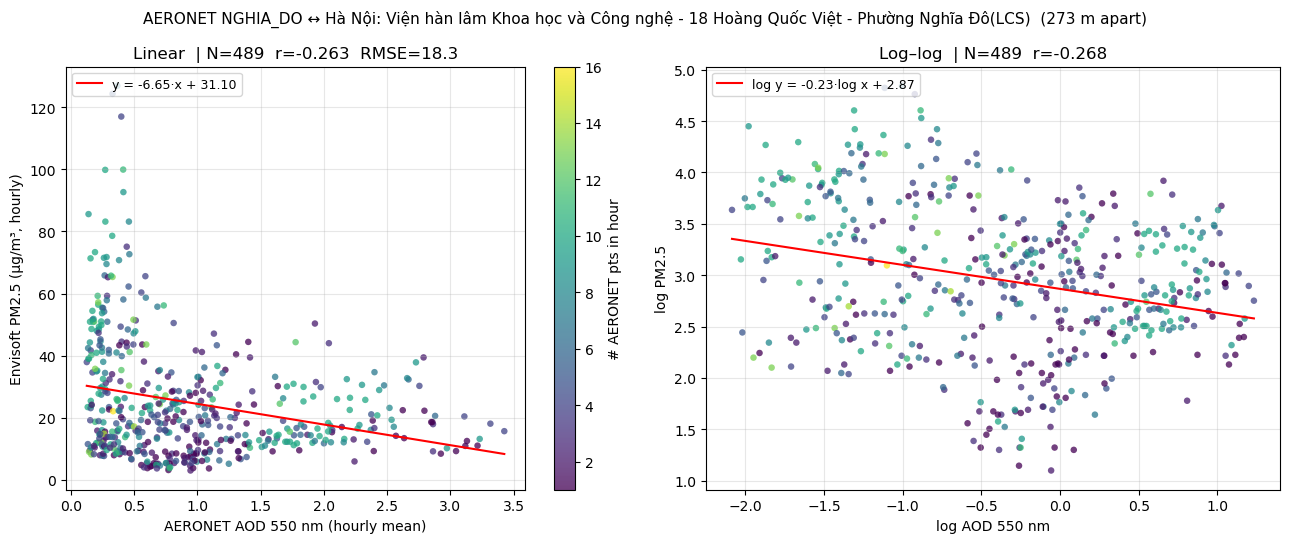

Linear   : {'slope': np.float64(-6.649237098312194), 'intercept': np.float64(31.100015992444725), 'r': np.float64(-0.2626683605738579), 'p': np.float64(3.6909890659840754e-09), 'rmse': 18.341115408773053, 'n': 489}
Log–log  : {'slope': np.float64(-0.2335279431379698), 'intercept': np.float64(2.866438646349246), 'r': np.float64(-0.2680936650693694), 'p': np.float64(1.702682804756142e-09), 'rmse': 0.6983244159981967, 'n': 489}


In [6]:
def fit_and_stats(x, y):
    slope, intercept, r, p, se = stats.linregress(x, y)
    rmse = float(np.sqrt(np.mean((y - (slope*x + intercept))**2)))
    return dict(slope=slope, intercept=intercept, r=r, p=p, rmse=rmse, n=len(x))

x = pairs['aod_550'].to_numpy()
y = pairs['pm25'].to_numpy()
s_lin = fit_and_stats(x, y)

mask  = (x > 0) & (y > 0)
lx, ly = np.log(x[mask]), np.log(y[mask])
s_log = fit_and_stats(lx, ly)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
sc = ax.scatter(x, y, c=pairs['n_aod'], cmap='viridis', s=22, alpha=0.75, edgecolor='none')
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, s_lin['slope']*xs + s_lin['intercept'], 'r-', lw=1.5,
        label=f"y = {s_lin['slope']:.2f}·x + {s_lin['intercept']:.2f}")
ax.set_xlabel('AERONET AOD 550 nm (hourly mean)')
ax.set_ylabel('Envisoft PM2.5 (µg/m³, hourly)')
ax.set_title(f"Linear  | N={s_lin['n']}  r={s_lin['r']:.3f}  RMSE={s_lin['rmse']:.1f}")
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='# AERONET pts in hour')

ax = axes[1]
ax.scatter(lx, ly, c=pairs.loc[mask, 'n_aod'], cmap='viridis', s=22, alpha=0.75, edgecolor='none')
lxs = np.linspace(lx.min(), lx.max(), 100)
ax.plot(lxs, s_log['slope']*lxs + s_log['intercept'], 'r-', lw=1.5,
        label=f"log y = {s_log['slope']:.2f}·log x + {s_log['intercept']:.2f}")
ax.set_xlabel('log AOD 550 nm')
ax.set_ylabel('log PM2.5')
ax.set_title(f"Log–log  | N={s_log['n']}  r={s_log['r']:.3f}")
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(
    f"AERONET {AERONET_STATION} ↔ {env_row['stationName']}  ({env_row['dist_m']:.0f} m apart)",
    fontsize=11)
plt.tight_layout()
plt.show()

print('Linear   :', s_lin)
print('Log–log  :', s_log)

## 6. Collocations over time

Overlay the AOD and PM2.5 series on twin y-axes, with collocated pairs highlighted. This makes synoptic episodes visible — winter haze events tend to drive both up together, while moisture/RH events can move PM2.5 without AOD.

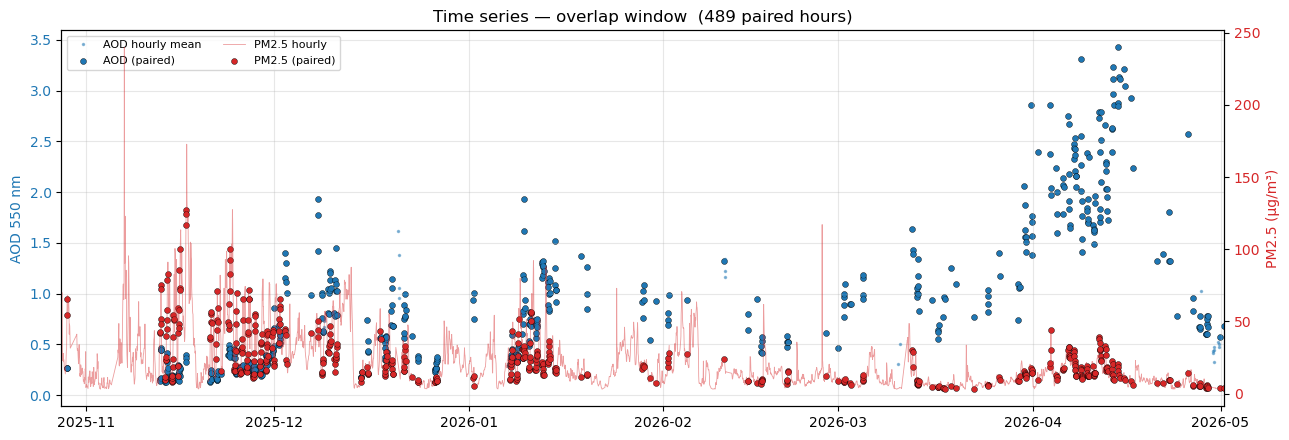

In [7]:
fig, ax1 = plt.subplots(figsize=(13, 4.5))

ax1.plot(aod_hr['hour'], aod_hr['aod_550'], '.', ms=3, color='C0', alpha=0.45, label='AOD hourly mean')
ax1.scatter(pairs['hour'], pairs['aod_550'], s=18, color='C0', edgecolor='k', lw=0.3, label='AOD (paired)')
ax1.set_ylabel('AOD 550 nm', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_xlim(overlap_start, overlap_end)

ax2 = ax1.twinx()
ax2.plot(pm_hr['hour'], pm_hr['pm25'], '-', lw=0.6, color='C3', alpha=0.45, label='PM2.5 hourly')
ax2.scatter(pairs['hour'], pairs['pm25'], s=18, color='C3', edgecolor='k', lw=0.3, label='PM2.5 (paired)')
ax2.set_ylabel('PM2.5 (µg/m³)', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

ax1.set_title(f"Time series — overlap window  ({len(pairs)} paired hours)")
ax1.grid(alpha=0.3)
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 7. (Optional) Save collocated pairs

Uncomment if you want a portable CSV for downstream regression / EDA.

In [8]:
# out = Path('/home/work1/projects/Air_Quality/AERONET/aod_pm25_nghia_do_pairs.csv')
# pairs.to_csv(out, index=False)
# print('wrote', out, len(pairs), 'rows')